In [1]:
##importing libraries
import io
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from dipy.segment.mask import median_otsu
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.font_manager as fm
from IPython.display import display, Image
import time

c:\Users\Acer\Desktop\Saroj_Project\IVIM_Autoencoder\ivimvnv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# #Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


In [3]:
!nvidia-smi

Sat Aug 15 12:02:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.44                 Driver Version: 591.44         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P8              5W /   50W |     395MiB /   4096MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
##pytorch details
!pip show torch

Name: torch
Version: 2.8.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: c:\users\acer\desktop\saroj_project\ivim_autoencoder\ivimvnv\lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, sympy, typing-extensions
Required-by: monai, torchaudio, torchvision


In [5]:
torch.__version__

'2.8.0+cu128'

In [6]:
# ##Checking torch version, cuda, GPU and memory 
# print(torch.__version__)              # Should show +cu128 (not +cpu)

# print(torch.cuda.is_available())      # Should be True
# # print(torch.cuda.get_device_name(0))  # Should show "NVIDIA GeForce GTX 1650 Ti"
# print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

## **DATASET**

In [7]:
##loding data
if not torch.cuda.is_available():
    path = "/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/notebooks/BRAIN"
else:
    path = "C:\\Users\\Acer\\Desktop\\Saroj_Project\\IVIM_Autoencoder\\notebooks\\BRAIN"

raw_data=nib.load(path+"/data.nii.gz")
mri_data=raw_data.get_fdata()
print(mri_data.shape)

(256, 256, 54, 21)


## **Data description**
1. H: Height of one image in the sequence
2. W: Width of one image in the sequence
3. D: Depth of images or Number of images in the sequence
4. C: Number of channels (like 3 RGB or b-values)

In [8]:
# Load b-values from the file
with open(path+"/bvalues.bval", "r") as f:
    bvals_str = f.read().split()
bvals_arr = np.array([float(b) for b in bvals_str], dtype=np.float32)

print(f"Loaded b-values: {bvals_arr}")
print(f"Number of b-values (N_b): {len(bvals_arr)}")

Loaded b-values: [   0.   10.   20.   30.   40.   60.   80.  100.  120.  140.  160.  180.
  200.  300.  400.  500.  600.  700.  800.  900. 1000.]
Number of b-values (N_b): 21


In [9]:
bvals_arr

array([   0.,   10.,   20.,   30.,   40.,   60.,   80.,  100.,  120.,
        140.,  160.,  180.,  200.,  300.,  400.,  500.,  600.,  700.,
        800.,  900., 1000.], dtype=float32)

## **DATA PREPROCESSING FOR SIMILAR NEIGHBOURING PIXELS EXTRACTION**

In [10]:
# img = raw_train_data[:,:,20,0]
# #for standardize the pixel values
# # mean = np.mean(img)
# # std = np.std(img)
# # img = img-mean
# # img = img/std
# plt.hist(img.flatten(),bins=200)
# plt.show()


In [11]:
#Slice axis 3 (b-value) at index 0, keeping all H, W, and D
b0_raw = mri_data[:, :, :, 0]  #(256, 256, 54) -> (H, W, D)

# Generate the mask using the correct 3D spatial volume
_, otsu_mask = median_otsu(b0_raw, median_radius=3, numpass=2)
brain_msk = otsu_mask.astype(np.uint8)   # (256, 256, 54) -> (H, W, D)

#Correct spatial dimension
print("Mask shape (H, W, D):", brain_msk.shape)  #(256, 256, 54)


Mask shape (H, W, D): (256, 256, 54)


In [12]:
# #Slice Brain Masks to Match
# train_mask = brain_msk[:, :, :train_end]
# val_mask   = brain_msk[:, :, train_end:val_end]
# test_mask  = brain_msk[:, :, val_end:]

# print(f'shape of train: {train_mask.shape}')
# print(f'shape of val: {val_mask.shape}')
# print(f'shape of test: {test_mask.shape}')

In [13]:
def spatial_slab_split(data, mask, val_ratio=0.15, test_ratio=0.15, buffer_slices=1):
    """
    Splits 3D/4D dMRI brain data into Train/Val/Test along Z-axis slabs
    with buffer slice margins to prevent spatial leakage.
    """
    H, W, D = mask.shape
    num_val = int(D * val_ratio)
    num_test = int(D * test_ratio)
    num_train = D - num_val - num_test - (2 * buffer_slices)
    
    train_end = num_train
    val_start = train_end + buffer_slices
    val_end = val_start + num_val
    test_start = val_end + buffer_slices
    
    train_mask = np.zeros_like(mask)
    val_mask   = np.zeros_like(mask)
    test_mask  = np.zeros_like(mask)
    
    train_mask[:, :, :train_end] = mask[:, :, :train_end]
    val_mask[:, :, val_start:val_end] = mask[:, :, val_start:val_end]
    test_mask[:, :, test_start:] = mask[:, :, test_start:]
    
    print(f"Train slices: 0..{train_end-1}")
    print(f"Val slices:   {val_start}..{val_end-1} (Buffer dropped: {train_end}..{val_start-1})")
    print(f"Test slices:  {test_start}..{D-1} (Buffer dropped: {val_end}..{test_start-1})")
    
    return train_mask, val_mask, test_mask

In [14]:
train_mask, val_mask, test_mask = spatial_slab_split(brain_msk, brain_msk, val_ratio=0.15, test_ratio=0.15, buffer_slices=1)

Train slices: 0..35
Val slices:   37..44 (Buffer dropped: 36..36)
Test slices:  46..53 (Buffer dropped: 45..45)


In [15]:
##spliting data into train, val and test
raw_train_data = mri_data * train_mask[:, :, :, np.newaxis]
raw_val_data   = mri_data * val_mask[:, :, :, np.newaxis]
raw_test_data  = mri_data * test_mask[:, :, :, np.newaxis]

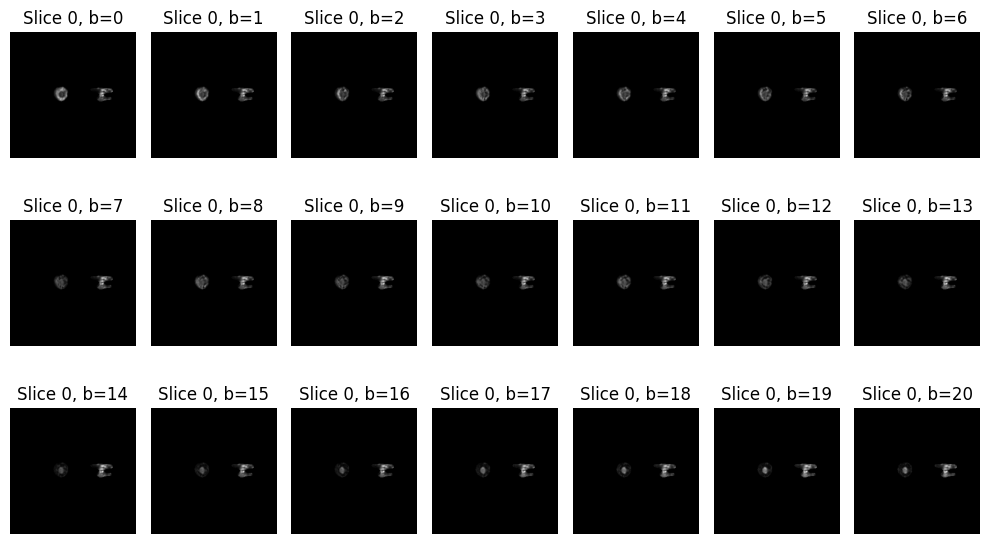

In [16]:
##displaying the 2 slice of mri data over 21 b-value
fig, ax = plt.subplots(3,7, figsize=(10,6))

# Flatten the 2D array of axes into a 1D array for easier iteration
flat_axes = ax.ravel()

plot_counter = 0
# Iterate over the first three slices (depth dimension) of the MRI data
for i in range(raw_train_data[:,:,:3,:].shape[2]):
  # Iterate over all b-values
  for j in range(raw_train_data.shape[3]): # j will be 0 to 20 b-values
    if plot_counter < len(flat_axes): # Check if there are still subplots available
      current_ax = flat_axes[plot_counter]
      current_ax.imshow(raw_train_data[:,:,i,j], cmap='gray')
      current_ax.set_title(f"Slice {i}, b={j}") # Add a title for context
      current_ax.axis('off') # Turn off axis labels for cleaner display
      plot_counter += 1

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

In [17]:
##process in the chunk to speed up
def process_chunk(padded_px, padded_b0, y, x, dy, dx,
                    center_flat_idx, target_slots, b_value):
    """
    Broadcasting Technique:
      Vectorized core, run on one chunk of pixels at a time so peak memory
    stays bounded regardless of total voxel count N.
    """

    n = len(y)

    ##Broadcasting technique to speed up the calculation
    #Build 5x5 neighborhood (25 positions per pixel) fetch using 5x5 window
    yy = y[:, None] + dy[None, :]
    xx = x[:, None] + dx[None, :]

    ##similar neighbouring pixels calculation
    b0_neighbors = padded_b0[yy, xx]              # (n, 25)
    center_b0 = padded_b0[y, x]                     # (n,)
    similarity = np.abs(center_b0[:, None] - b0_neighbors)  # (n, 25)

    ##a masking array of 25 boolean coordinate
    ##removing center coordinate from the extracted 5x5 similarity matrix
    keep = np.ones(25, dtype=bool)
    keep[center_flat_idx] = False

    ##indexing drops/remove center from the column where keep==false
    # Drops the center coordinates
    similarity = similarity[:, keep] # (n, 24)
    yy, xx = yy[:, keep], xx[:, keep]

    #sort the python list.sort() 
    #order indices says which column to pick per row  
    order = np.argsort(similarity, axis=1, kind='stable')  # (n, 24)
    top8_indices = order[:, :8]

    ##select values from an array along a specified axis using index arrays
    yy_top = np.take_along_axis(yy, top8_indices, axis=1)      # (n, 8)
    xx_top = np.take_along_axis(xx, top8_indices, axis=1)
    full_top8 = padded_px[:, yy_top, xx_top]  # (b_value, n, 8)

    ##initialize the 3x3 patch of most similar pixels
    block = np.zeros((n, 3, 3, b_value), dtype=np.float32)
    center_vals = padded_px[:, y, x]             # (b_value, n)
    block[:, 1, 1, :] = center_vals.T

    vals = np.transpose(full_top8, (1, 2, 0))           # (n, 8, b_value)
    block[:, target_slots[:, 0], target_slots[:, 1], :] = vals

    return block


##extracting the similar neighbouring pixels patches 
def similar_neighborhood_patch(data, brain_masker, chunk_size=2000):
    H, W, D, b_value = data.shape

    y_factor = 2.0 / (H - 1) if H > 1 else 1.0
    x_factor = 2.0 / (W - 1) if W > 1 else 1.0

    similar_patch, center_coord, norm_cent_coord  = [], [], []

    #Looping over each slices
    for i in range(D):
      slices_data = data[:, :, i, :]

      mri_slice = np.transpose(slices_data, (2, 0, 1))  # (b, H, W)
      
      #brain mask slicing (no transpose needed for 2D)
      brain_mask_slice = brain_masker[:, :, i]  # (H, W)

      ##Intensity normalization
      b0_original = mri_slice[0].copy()
      ##select only valid pixels
      b0_valid_px = np.where(b0_original==0, 1e-8, b0_original)
      ##normalize
      mri_slice_norm = mri_slice/b0_valid_px[None:, :]

      #Threshold
      #Finds the actual intensity mean of the b=0 brain pixels, not mask density
      b0_image = mri_slice[0]
      b0_img_mean = np.mean(b0_image[brain_mask_slice > 0]) if np.any(brain_mask_slice > 0) else 0
      b0_threshold = 0.50 * b0_img_mean

      # Find indices based on corrected 2D mask and threshold
      brain_indices = np.argwhere((brain_mask_slice > 0) & (b0_image >= b0_threshold))
      N = len(brain_indices)
      print(f"Slice {i}/{D-1}: Processing {N} brain pixels to build 2D similarity blocks")

      ##if number of voxels is zero continue calculation
      if N == 0:
          continue
      
      ##padding tensors
      ##padded signal at b-value=0
      padded_px = np.pad(mri_slice_norm, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
      padded_b0 = np.pad(b0_original, ((2, 2), (2, 2)), mode='constant', constant_values=0)


      ##x and y coordinates of brain indices with padding
      y_all = (brain_indices[:, 0] + 2).astype(np.int32)
      x_all = (brain_indices[:, 1] + 2).astype(np.int32)

      ##array ranging from -2 to 3, for generating a 5x5 window: array([-2, -1,  0,  1,  2])
      ##5x5 window matrix
      ##flatten them in 1d array
      ##offset coordinate index for central pixel
      offs = np.arange(-2, 3, dtype=np.int32)
      dy, dx = np.meshgrid(offs, offs, indexing='ij')
      dy, dx = dy.ravel(), dx.ravel()
      center_flat_idx = 12  #(0,0) offset's position in the flatten 25-length grid

      ##initialize the empty neighbors slot to store top neighbor pixels later in calculation
      top_neighbors_slot = np.array([
          (a, b) for a in range(3) for b in range(3) if not (a == 1 and b == 1)
          ])

      ##initialize the empty similar neighbourhood block array
      similar_neig_block = np.zeros((N, 3, 3, b_value), dtype=np.float32)

      ##actual similar neighbourhood data calculated in chunks and store in pre-defined similar_neig_block
      for start in range(0, N, chunk_size):
          end = min(start + chunk_size, N)
          similar_neig_block[start:end] = process_chunk(padded_px, padded_b0, y_all[start:end], x_all[start:end],
                                                    dy, dx, center_flat_idx, top_neighbors_slot, b_value)

      center_coords = list(map(tuple, brain_indices))
      y0 = brain_indices[:, 0] * y_factor - 1.0
      x0 = brain_indices[:, 1] * x_factor - 1.0
      center_norm_coord = list(zip(y0.tolist(), x0.tolist()))

      similar_patch.append(similar_neig_block)
      center_coord.append(center_coords)
      norm_cent_coord.append(center_norm_coord)
      
    print("Processing completed.")
    return similar_patch, center_coord, norm_cent_coord


In [18]:
#Run Patches extraction function independently on each chunk
print("Extracting Training Patches")
train_patches, _, train_norm_coords = similar_neighborhood_patch(raw_train_data, train_mask)

print("\nExtracting Validation Patches")
val_patches, _, val_norm_coords = similar_neighborhood_patch(raw_val_data, val_mask)

print("\nExtracting Testing Patches")
test_patches, test_coords, test_norm_coords = similar_neighborhood_patch(raw_test_data, test_mask)

#Concatenate slices into monolithic numpy arrays
X_train = np.concatenate(train_patches, axis=0)  # (N_train, 3, 3, b_value)
X_val   = np.concatenate(val_patches, axis=0)    # (N_val, 3, 3, b_value)
X_test  = np.concatenate(test_patches, axis=0)   # (N_test, 3, 3, b_value)

# Flatten the coordinate lists for conditional context
coord_train = np.array([c for slice_c in train_norm_coords for c in slice_c], dtype=np.float32)
coord_val   = np.array([c for slice_c in val_norm_coords for c in slice_c], dtype=np.float32)
coord_test  = np.array([c for slice_c in test_norm_coords for c in slice_c], dtype=np.float32)


Extracting Training Patches
Slice 0/53: Processing 1100 brain pixels to build 2D similarity blocks
Slice 1/53: Processing 1311 brain pixels to build 2D similarity blocks
Slice 2/53: Processing 1669 brain pixels to build 2D similarity blocks
Slice 3/53: Processing 2411 brain pixels to build 2D similarity blocks
Slice 4/53: Processing 3326 brain pixels to build 2D similarity blocks
Slice 5/53: Processing 4100 brain pixels to build 2D similarity blocks
Slice 6/53: Processing 4728 brain pixels to build 2D similarity blocks
Slice 7/53: Processing 5202 brain pixels to build 2D similarity blocks
Slice 8/53: Processing 5564 brain pixels to build 2D similarity blocks
Slice 9/53: Processing 5959 brain pixels to build 2D similarity blocks
Slice 10/53: Processing 6853 brain pixels to build 2D similarity blocks
Slice 11/53: Processing 8110 brain pixels to build 2D similarity blocks
Slice 12/53: Processing 9335 brain pixels to build 2D similarity blocks
Slice 13/53: Processing 10477 brain pixels to 

In [19]:
X_train[0]

array([[[1.        , 0.7744465 , 0.8072117 , 0.82781136, 0.7441167 ,
         0.69936264, 0.74761045, 0.5867344 , 0.60328937, 0.53246814,
         0.5386402 , 0.4151038 , 0.44574443, 0.31591532, 0.22135457,
         0.20950624, 0.18000263, 0.1953747 , 0.13910598, 0.15617156,
         0.09742675],
        [1.        , 0.5533619 , 0.32959533, 0.74360824, 0.4694777 ,
         0.47384518, 0.1972078 , 0.14794442, 0.35720235, 0.34725583,
         0.30239362, 0.28878242, 0.22946423, 0.1247082 , 0.14151078,
         0.1005993 , 0.11296628, 0.09627642, 0.12547806, 0.11951357,
         0.10411981],
        [1.        , 0.6769471 , 0.4590843 , 0.92023176, 0.5630377 ,
         0.7006244 , 0.526972  , 0.37602347, 0.6541385 , 0.5708311 ,
         0.4515527 , 0.44367996, 0.28467622, 0.2368071 , 0.1921778 ,
         0.16893184, 0.1782051 , 0.12974456, 0.13714117, 0.1039773 ,
         0.12513176]],

       [[1.        , 0.65984577, 0.670416  , 0.6672307 , 0.64407486,
         0.62850356, 0.5571481 , 0.

In [20]:
# ##display 3x3 block
# plt.imshow(X_train[0][0,:,:,0], cmap='gray') # Display the signal at 21 b-value of the first block's middle depth slice
# plt.show()

# X_train[0] ##shape=(119110, 3, 3, 21)

# x=torch.from_numpy(X_train[0]).float()
# x.shape


# ##shape=(119110, 3, 3, 21) -----> shape=(119110, 21, 3, 3) ----> Idx shape=(0, 3, 1, 2)
# x1=x.permute(2, 0, 1) 
# x1.shape


# print(x1[:,0:1, :, : ])
# x1[:, 0:1, :, : ].shape ##torch.Size([21, 3, 3])


# x1[:,0:1,:,:][0].shape

# ##b0_image
# plt.imshow(x1[:, 0:1, :, :][0], cmap='gray')
# plt.show()


# # Visualise the highest b-value (e.g., index -1), with non-zero b-value
# plt.imshow(x1[0, -1, :, :], cmap="gray", vmin=0, vmax=1)
# plt.colorbar()
# plt.show()

In [21]:
##A custom data creator function
class DiffusionDataset(Dataset):
    def __init__(self, similar_patches, condition):
        """
        similar_patches: NumPy array of shape (N, 3, 3, b_values)
        condition (list of coordinates): NumPy array of shape (N, 2) 
        """
        # data is a list of slices, concatenate it into a monolithic array 
        # inside (__init__) to protect from list indexing bugs
        ##checking whether it is a list or array
        if isinstance(similar_patches, list):
            self.patches = np.concatenate(similar_patches, axis=0)
        else:
            self.patches = similar_patches

        # Convert the entire condition dataset to a PyTorch tensor at initialization. 
        # This avoids slow memory re-allocations in __getitem__
        self.condition = torch.tensor(np.array(condition), dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        #convert the individual patch array to a tensor
        x = torch.from_numpy(self.patches[idx]).float()

        # checking dimension for reshaping
        if x.dim() == 3:
            x = x.permute(2, 0, 1)      #(3, 3, b_values) -> (b_values, 3, 3)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)   #(N, 3, 3, b_values) -> (N, b_values, 3, 3)
        else:
            raise ValueError(f"Unexpected tensor shape {tuple(x.shape)}")

        # Clean, fast index fetch for the condition vector
        y = self.condition[idx]
        return x, y



In [22]:
#INSTANTIATE THE TORCH DATALOADERS
# Voxel-wise/Patch regression networks process data fast. A large batch size 
# improves training speed and stabilizes the CVAE latent space optimization.
BATCH_SIZE = 128  

train_dataset = DiffusionDataset(X_train, coord_train)
val_dataset   = DiffusionDataset(X_val, coord_val)
test_dataset  = DiffusionDataset(X_test, coord_test)

# Training, Validation and Testing data loaders
#Shuffle=True is strictly applied only to training data
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


print(f"Data Loaders successfully created:")
print(f"Train Batches:      {len(train_loader)} (Total patches: {len(train_dataset)})")
print(f"Validation Batches: {len(val_loader)} (Total patches: {len(val_dataset)})")
print(f"Testing Batches:    {len(test_loader)} (Total patches: {len(test_dataset)})")



Data Loaders successfully created:
Train Batches:      3639 (Total patches: 465798)
Validation Batches: 1073 (Total patches: 137341)
Testing Batches:    553 (Total patches: 70681)


In [23]:
# Fetch one test batch and check
for train_x, train_coord in train_loader:
    print(f"Batch X Shape (Expects [4, b_values, 3, 3]): {train_x.shape}")
    print(f"Batch Y Shape (Expects [4, 2]):           {train_coord.shape}")
    print(f"X_train values: {train_x[0,:,:,:]}")
    break


Batch X Shape (Expects [4, b_values, 3, 3]): torch.Size([128, 21, 3, 3])
Batch Y Shape (Expects [4, 2]):           torch.Size([128, 2])
X_train values: tensor([[[1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        [[0.9407, 0.9814, 0.9766],
         [1.0077, 0.9985, 1.0157],
         [0.9913, 0.9694, 0.9710]],

        [[0.9627, 0.9836, 1.0023],
         [0.9716, 0.9667, 0.9921],
         [0.9760, 0.9677, 0.9673]],

        [[0.9699, 0.9558, 0.9534],
         [1.0019, 0.9944, 1.0033],
         [0.9723, 0.9928, 0.9888]],

        [[0.9533, 0.9835, 1.0098],
         [0.9804, 0.9767, 0.9817],
         [0.9692, 0.9733, 0.9721]],

        [[0.9308, 0.9699, 0.9599],
         [0.9756, 0.9733, 0.9595],
         [0.9562, 0.9435, 0.9551]],

        [[0.9366, 0.9641, 0.9326],
         [0.9538, 0.9757, 0.9458],
         [0.9809, 0.9682, 0.9411]],

        [[0.8831, 0.9159, 0.9290],
         [0.9404, 0.9230, 0.9459],
         [0.8970, 0.9050, 0.9

## **PHYSIOLOGICAL BI-EXPONENTIAL SIGNAL EQUATION**

In [24]:
##Physics IVIM signal function
def ivim_biex_signal(theta, b_vals):
    ##IVIM parameters
    D = theta[:, 0:1]
    Ds = theta[:, 1:2]
    f = theta[:, 2:3]

    #b values broadcastable if b-value is 1D array
    if b_vals.dim()<=2:
        b = b_vals.view(1,-1, 1, 1)
    else:
        b = b_vals.reshape(1, -1, 1, 1)
    
    ##perfusion signal due to the flow of blood
    s_perf = f*torch.exp(-b * Ds)
    ##True diffusion signal due to water molecules in tissues
    s_diff = (1-f)*torch.exp(-b*D)
    ##bi-exponential signal
    s_sum = s_perf + s_diff
    return s_sum, s_perf, s_diff

## **MODEL ARCHITECTURE**

## **UNCERTAINTY QUANTIFICATION WHILE ESTIMATING PARAMETERS**

In [25]:
##MonteCarlo Dropout
class MCDropout(nn.Module):
    """"
    1D dropout layer which enforces the dropout layer to stay active even in
    model evaluation called inference.
    """
    def __init__(self, p:float):
        super().__init__()
        self.p = p
        self.mc_active = True ##by default is always on

    def forward(self, input: torch.Tensor):
        use_dropout = self.mc_active or self.training
        return F.dropout(input, p=self.p, training=use_dropout)

In [26]:
def ivim_signal_variance(D, Ds,f,D_var,Ds_var,
                        f_var,bvalues,eps=1e-10,
                        base_var=1e-6,max_var=1.0):
    """
    Propagate D/Ds/f variance into IVIM signal variance.

    Parameter:
        D: predicted true diffusion, shape (B, 1, 3, 3)
        Ds: predicted pseudo-diffusion, shape (B, 1, 3, 3)
        f: predicted perfusion fraction, shape (B, 1, 3, 3)
        D_var: predicted variance of D, shape (B, 1, 3, 3)
        Ds_var: predicted variance of Ds, shape (B, 1, 3, 3)
        f_var: predicted variance of f, shape (B, 1, 3, 3)
        bvalues: b-values tensor
        eps: numerical floor
        base_var: small baseline signal variance to avoid collapse
        max_var: upper bound for signal variance

    Returns:
        signal_var: shape (B, num_bvalues, 3, 3)
    """

    b = bvalues.view(1, -1, 1, 1)

    exp_D = torch.exp(-b * D)
    exp_Ds = torch.exp(-b * Ds)

    dS_dD = -(1.0 - f) * b * exp_D
    dS_dDs = -f * b * exp_Ds
    dS_df = exp_Ds - exp_D

    signal_var = ( dS_dD.pow(2) * D_var + dS_dDs.pow(2) * Ds_var + dS_df.pow(2) * f_var + base_var)

    signal_var = torch.clamp(signal_var, min=eps, max=max_var)

    return signal_var

In [27]:
def heteroscedastic_signal_loss(recon,target,signal_var,bvalues=None,
                                eps=1e-10,mask_b0=True):
    """
    Gaussian heteroscedastic negative log-likelihood on reconstructed IVIM signal.

    Parameter:
        recon: predicted signal, shape (B, num_bvalues, 3, 3)
        target: observed signal, shape (B, num_bvalues, 3, 3)
        signal_var: predicted signal variance, shape (B, num_bvalues, 3, 3)
        bvalues: b-values tensor. If provided and mask_b0=True, b=0 is ignored.
        eps: numerical floor
        mask_b0: whether to exclude b=0 from the loss

    Returns:
        scalar loss
    """

    nll = 0.5 * (torch.log(signal_var + eps) + ((target - recon) ** 2) / (signal_var + eps))

    if mask_b0 and bvalues is not None:
        mask = (bvalues.view(1, -1, 1, 1) > 0).float().to(nll.device)
        mask = mask.expand_as(nll)

        masked_nll = nll * mask
        denom = mask.sum().clamp(min=1.0)

        return masked_nll.sum() / denom

    return nll.mean()

In [28]:
def ivim_physics_penalty(D, Ds, f, f_max=0.300):
    """
    Physics/physiological regularization for D, Ds, f.
    """

    f_prior = 0.20

    f_too_low = (f < 0.02).float()
    f_too_high = (f > f_max - 0.02).float()

    f_reg = (torch.mean((f - f_prior).pow(2) * f_too_low) * 10.0 + torch.mean((f - f_prior).pow(2) * f_too_high) * 10.0)

    #Enforces D* > D (pseudo-diffusion > true diffusion)
    diff_reg = torch.mean(F.relu(D - Ds + 1e-6) ** 2)

    #Spatial smoothness on 3x3 patch
    smooth_d_v = torch.mean((D[:, :, 1:, :] - D[:, :, :-1, :]) ** 2)
    smooth_ds_v = torch.mean((Ds[:, :, 1:, :] - Ds[:, :, :-1, :]) ** 2)
    smooth_d_h = torch.mean((D[:, :, :, 1:] - D[:, :, :, :-1]) ** 2)
    smooth_ds_h = torch.mean((Ds[:, :, :, 1:] - Ds[:, :, :, :-1]) ** 2)

    smoothness = smooth_d_v + smooth_ds_v + smooth_d_h + smooth_ds_h
    physics_penalty = (f_reg * 1.0 + diff_reg * 10.0 + smoothness * 0.1)
    return physics_penalty

In [29]:
##Physics informed IVIM cVAE
class PhysicsCVAE(nn.Module):
    """
    Physics-Informed Conditional Variational Autoencoder (PIcVAE) for IVIM parameter estimation.

    Architecture
    Encoder: 2D CNN on 3x3 multi-b-value patches(coordinate-free)
    Decoder: z + normalised spatial coords ---> IVIM bi-exponential forward model
    """

    D_min: torch.Tensor
    D_max: torch.Tensor
    D_range: torch.Tensor

    Ds_min: torch.Tensor
    Ds_max: torch.Tensor
    Ds_range: torch.Tensor

    f_min: torch.Tensor
    f_max: torch.Tensor
    f_range: torch.Tensor

    logvar_min: torch.Tensor
    D_logvar_max: torch.Tensor
    Ds_logvar_max: torch.Tensor
    f_logvar_max: torch.Tensor

    def __init__(self, 
                 in_channel:int, 
                 bvalues: torch.Tensor, 
                 latent_dim:int, 
                 coord_dim=2, 
                 bvals=None, 
                 dropout_p=0.10):
        """
        Parameters:
        in_channel  (int):   Number of b-values (input channels).
        bvalues     (Tensor): 1-D tensor of b-values (s/mm²).
        latent_dim  (int):   Dimensionality of latent vector z.
        coord_dim   (int):   Spatial coordinate dimensions (default 2 for x, y).
        dropout_p   (float): MC-Dropout probability in decoder.
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.coord_dim = coord_dim

        ##Physiological Constant ranges
        D_min, D_max = 0.0001, 0.004 #Water restriction boundaries
        Ds_min, Ds_max = 0.005, 0.020 #High-velocity capillary perfusion micro-circulation
        f_min, f_max = 0.000, 0.300 #Capillary plasma fraction cap(50%)

        ##registering b-values as buffer parameters
        self.register_buffer("bvalues", bvalues.view(1, -1, 1, 1)) 

        ##ENCODER NET
        # Input:  (B, in_channel, 3, 3)
        # Output: (B, 576)   [64 channels x 3 x 3, flattened]

        self.encoder_net = nn.Sequential(
            ##first conv layer
            nn.Conv2d(in_channel, 512, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=512),
            nn.GELU(),
            MCDropout(0.40),

            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=256),
            nn.GELU(),
            MCDropout(0.30),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=128),
            nn.GELU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=128),
            nn.GELU(),
            MCDropout(0.20),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=64),
            nn.GELU(),
            nn.Flatten()
        )

        ## 64 CNN output channel, 3-Height, 3-Width 
        ##encoder output
        encoder_output_dim = 64*3*3


        ##mean and variance for latent space
        self.fc_mu = nn.Linear(encoder_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_output_dim, latent_dim)

        ##DECODER NET: conditioned on normalized spatial coordinates
        ##conditional vector layer
        self.de_coord_layer = nn.Sequential(
            nn.Linear(self.coord_dim, 8),
            nn.GELU()
        )

        ##combined 
        combined_decoder_size = self.latent_dim+8

        self.decoder_net = nn.Sequential(
            nn.Linear(combined_decoder_size, 512), 
            nn.GELU(),
            MCDropout(0.30),

            nn.Linear(512, 256),
            nn.GELU(),
            MCDropout(0.20),

            nn.Linear(256, 128),
            nn.GELU(),
            MCDropout(0.15),
            
            nn.Linear(128, 64),
            nn.GELU()
        )

        ##Decoder output for D,D*,f (mean and variance)
        self.param_mu_head = nn.Linear(64, 3*3*3)
        self.param_logvar_head = nn.Linear(64, 3*3*3)

        # Initialize parameter logvar bias to a reasonable starting scale
        nn.init.constant_(self.param_logvar_head.weight, 0.0)
        nn.init.constant_(self.param_logvar_head.bias, -6.0)

        # Ranges
        self.register_buffer("D_min",   torch.tensor(D_min,  dtype=torch.float32))
        self.register_buffer("D_max",   torch.tensor(D_max,  dtype=torch.float32))
        self.register_buffer("D_range", torch.tensor(D_max - D_min, dtype=torch.float32))

        self.register_buffer("Ds_min",   torch.tensor(Ds_min,  dtype=torch.float32))
        self.register_buffer("Ds_max",   torch.tensor(Ds_max,  dtype=torch.float32))
        self.register_buffer("Ds_range", torch.tensor(Ds_max - Ds_min, dtype=torch.float32))

        self.register_buffer("f_min",   torch.tensor(f_min,  dtype=torch.float32))
        self.register_buffer("f_max",   torch.tensor(f_max,  dtype=torch.float32))
        self.register_buffer("f_range", torch.tensor(f_max - f_min, dtype=torch.float32))

        # Allow parameter variances to scale up to the full range squared, 
        # but give logvar room up to 0.0 (variance of 1.0 in normalized parameter space)
        self.register_buffer("logvar_min",    torch.tensor(-15.0, dtype=torch.float32))
        self.register_buffer("D_logvar_max",  torch.tensor(-4.0,  dtype=torch.float32))
        self.register_buffer("Ds_logvar_max", torch.tensor(-2.0,  dtype=torch.float32))
        self.register_buffer("f_logvar_max",  torch.tensor(0.0,   dtype=torch.float32))

    ##Split the 27 raw outputs into 3 group (D,Ds,f)
    def split_raw(self, raw_output):
        """ 
        Split Raw output: (B, 27)
        Returns:
            D:  (B, 1, 3, 3)
            Ds: (B, 1, 3, 3)
            f:  (B, 1, 3, 3)
        """
        d_chunk, ds_chunk, f_chunk = torch.chunk(raw_output, chunks=3, dim=1)

        #Reshape to 2D spatial patches: Each becomes (B, 1, 3, 3)
        d_raw = d_chunk.view(-1, 1, 3, 3)
        ds_raw = ds_chunk.view(-1, 1, 3, 3)
        f_raw = f_chunk.view(-1, 1, 3, 3)
        return d_raw, ds_raw, f_raw
    
    # Physical parameter constraints
    def constrain_mean(self, raw_params):
        """
        Split (B, 27) into 3 param maps with physical constraints
        Returns: theta (B, 3, 3, 3) stacked as [D, D*, f]
                Individual: D (B,1,3,3), Ds (B,1,3,3), f (B,1,3,3)
        """

        ##splitting 27 raw outputs into 3 groups of 9 having shape (B, 1, 3, 3)
        d_raw, ds_raw, f_raw = self.split_raw(raw_output=raw_params)

        ##IVIM THREE PARAMETERS
        ##True diffusion
        # Shifted softplus: phi(x) = ln(1+e^x) - ln(2)  ->  output in [0, inf)
        # At x = 0: phi(0) = 0  (standard softplus gives ln(2) ~ 0.693 here)
        zero_tensor = torch.zeros_like(d_raw)
        t_d = F.softplus(d_raw)-F.softplus(zero_tensor)
        t_D = torch.clamp(t_d, min=0.0, max=1.0)

        ##Perfusion - pseudo-diffusion
        p_ds = F.softplus(ds_raw)-F.softplus(zero_tensor)
        p_Ds = torch.clamp(p_ds, min=0.0, max=1.0)

        ##perfusion fraction: Perfusion fraction remains a standard native sigmoid percentage 
        p_f = torch.sigmoid(f_raw)

        ##Scaling the three parameters using biophysiological constants 
        D  = self.D_min + t_D*self.D_range
        Ds = self.Ds_min + p_Ds*self.Ds_range
        f  = self.f_min + p_f*self.f_range

        ##Stacking parameters safely back into the (B, 3, 3, 3) shape
        theta_params = torch.cat([D, Ds, f], dim=1)

        return D, Ds, f, theta_params

    ## CVAE methods
    ##ENCODER
    def Encode(self, x_similar_patch:torch.Tensor):
        """Encoder: multi-b-value patch -> (mu, logvar). No coord conditioning"""
        image_vector = self.encoder_net(x_similar_patch) #image feature maps with shape (B, 576) 
        mu = self.fc_mu(image_vector)  
        logvar = self.fc_logvar(image_vector)
        return mu, logvar

    ##LATENT SPACE
    ##Appying reparameterization trick 
    #way to sample the latent variable(z) from the distribution of N(mu, variance)
    def reparameterize(self, mu, logvar):
        """Standard VAE reparameterisation trick: z = mu + sigma * epsilon"""
        ##standard deviation from log-variance
        std = torch.exp(0.5 * logvar) 
        ##epsilon is a noise variable with randomness on it
        eps = torch.randn_like(std) 
        ##reparameterized sample
        z = mu + eps*std
        return z

    #Constrain log-variances and convert to variances
    def compute_params_variance(self, raw):
        """
        raw: (B, 27), interpreted as raw log-variance

        Returns:
            variances: (D_var, Ds_var, f_var)
            logvars:   (D_logvar, Ds_logvar, f_logvar)
        """
        d_raw, ds_raw, f_raw = self.split_raw(raw)

        D_logvar = torch.clamp(d_raw,
                               min=self.logvar_min,
                               max=self.D_logvar_max)
        
        Ds_logvar = torch.clamp(ds_raw,
                                min=self.logvar_min,
                                max=self.Ds_logvar_max)
        f_logvar = torch.clamp(f_raw,
                               min=self.logvar_min,
                               max=self.f_logvar_max)
        
        D_var = torch.exp(D_logvar)
        Ds_var = torch.exp(Ds_logvar)
        f_var = torch.exp(f_logvar)

        variances = (D_var, Ds_var, f_var)
        logvars = (D_logvar, Ds_logvar, f_logvar)

        return variances, logvars
    
    ##DECODER
    def Decode(self, z_sample:torch.Tensor, coord:torch.Tensor):
        """
        Decoder: latent(z) + spatial coords - IVIM bi-exponential signal

        Parameters:
        ----------
        z     : (B, latent_dim)   sampled latent vector
        coord : (B, 2)            normalised spatial coordinates

        Returns
        -------
        s_total    : (B, C_bvals, 3, 3)  reconstructed signal
        components : tuple(s_total, s_perf, s_diff)
        IVIM parameters : tuple(theta, D, Ds, f)
        """
        ##transform the coordinates into vector form in shape (B, coord)
        coord_vec = self.de_coord_layer(coord) ##(B, 8)
        ##coordinate vectors and z-samples combine together again
        de_input = torch.cat([z_sample, coord_vec], dim=1) ##(B, latent_dim+2)
        ##decoder layer generates the raw parameters
        raw_pars = self.decoder_net(de_input) ##(B, 27)

        mean_raw = self.param_mu_head(raw_pars)
        logvar_raw = self.param_logvar_head(raw_pars)

        ##apply physical constraint
        D, Ds, f, theta = self.constrain_mean(mean_raw)

        variances, logvars = self.compute_params_variance(logvar_raw)

        ##feeding into the external IVIM bi-exponential function
        s_total, s_perf, s_diff = ivim_biex_signal(theta, self.bvalues)

        components = (s_total, s_perf, s_diff)
        params = (theta, D, Ds, f)

        return s_total, components, params, variances, logvars

    ##FORWARD PASS
    def forward(self, x_inputs:torch.Tensor, c_condition:torch.Tensor):
        """ Full forward pass: encode -> reparameterise -> decode """
        ##Encoder
        mu, log_var = self.Encode(x_similar_patch=x_inputs)
        ##Reparameterization
        z = self.reparameterize(mu, log_var)
        ##Decoder
        recon, components, parameters, variances, logvars = self.Decode(z, coord=c_condition)
        return recon, mu, log_var, components, parameters, variances, logvars

    # MC Dropout control — toggle for training vs validation vs UQ
    def mc_dropout_set(self, active: bool):
        """Enable/disable MC mode for all MCDropout layers.

        Parameters
        active : bool
            True: dropout always ON  (for MC uncertainty estimation)
            False: dropout follows normal train/eval (for deterministic val)
        """
        for module in self.modules():
            if isinstance(module, MCDropout):
                module.mc_active = active

    #RECONSTRUCTION LOSS WITH KL-DIVERGENCE
    ##SUM is change into mean for reconstruction
    def cvae_loss(self, recons: torch.Tensor,
                    x: torch.Tensor,
                    mu: torch.Tensor,
                    logvar: torch.Tensor,
                    params,
                    kl_weight: float,
                    param_reg_weight: float,
                    variances,
                    eps=1e-10
                    ):
            """
            Reconstruction loss + KL divergence + physics regularization.
            """
            x = torch.nan_to_num(x, nan=0.0)
            recons = torch.nan_to_num(recons, nan=0.0)
            # Unpack parameters
            if len(params) == 4:
                _, D, Ds, f = params
            elif len(params) == 3:
                D, Ds, f = params
            else:
                raise ValueError("params must be either (theta, D, Ds, f) or (D, Ds, f).")
            D_var, Ds_var, f_var = variances

            # Propagate parameter variance to signal variance
            signal_var = ivim_signal_variance(D=D, Ds=Ds,f=f,D_var=D_var,
                                        Ds_var=Ds_var, f_var=f_var, bvalues=self.bvalues,
                                        eps=eps)
            #Heteroscedastic reconstruction loss
            recon_loss = heteroscedastic_signal_loss(
                recon=recons,
                target=x,
                signal_var=signal_var,
                bvalues=self.bvalues,
                eps=eps,
                mask_b0=True
            )        
            ##reconstruction loss
            # recon_loss = F.mse_loss(recons, x, reduction="mean")
            latent_logvar = torch.clamp(logvar, min=-10.0, max=10.0)

            ##kl loss
            kl_loss = -0.5 * torch.mean(1 + latent_logvar - mu.pow(2) - latent_logvar.exp())

            ##total loss
            loss = recon_loss + kl_weight * kl_loss
    
            if param_reg_weight > 0 and params is not None:
                #params may be either (theta, D, Ds, f) or (D, Ds, f)
                if len(params) == 4:
                    _, D, Ds, f = params
                elif len(params) == 3:
                    D, Ds, f = params
                else:
                    raise ValueError("params must be either (theta, D, Ds, f) or (D, Ds, f)")
    
                physics_loss = ivim_physics_penalty(
                    D=D,
                    Ds=Ds,
                    f=f,
                    f_max=0.300
                )
                loss = loss + param_reg_weight * physics_loss
    
            #For monitoring only
            mse_loss = F.mse_loss(recons, x)
            
            if not torch.isfinite(loss):
                    loss = torch.nan_to_num(loss,nan=1.0,posinf=1.0,neginf=0.0)
            
            return loss, recon_loss.detach(), kl_loss.detach(), mse_loss.detach()

## **TRAINING PIPELINE**

In [36]:
##computing kl weights to optimize
def compute_kl_weight(epoch, warmup_epochs, anneal_epochs, kl_target):
    """
    Linear warmup + anneal schedule.
    epoch 0 to warmup_epochs-1:
        KL weight = 0
    epoch warmup_epochs to warmup_epochs + anneal_epochs - 1:
        linearly increase from kl_target / anneal_epochs to kl_target
    after that:
        KL weight = kl_target
    """
    if warmup_epochs < 0 or anneal_epochs < 0:
        raise ValueError("warmup_epochs and anneal_epochs must be non-negative.")

    if epoch < warmup_epochs:
        return 0.0

    if anneal_epochs == 0:
        return kl_target

    if epoch < warmup_epochs + anneal_epochs:
        progress = (epoch - warmup_epochs + 1) / float(anneal_epochs)
        progress = min(progress, 1.0)
        return progress * kl_target

    return kl_target

def safe_rmse(mse_value):
    """
    Safe RMSE calculation.
    Prevents sqrt(NaN) or sqrt(negative) warnings.
    """
    mse_value = float(mse_value)
    if not np.isfinite(mse_value):
        return np.nan
    mse_value = max(mse_value, 0.0)
    return np.sqrt(mse_value)


def execute_cvae_training(model,train_loader,val_loader,num_epochs,lr,device="cuda"):
    if isinstance(device, str):
        if device == "cuda" and not torch.cuda.is_available():
            device = "cpu"
        device = torch.device(device)

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)

    #Cosine annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    #Constants
    KL_TARGET = 0.005 #Moderate KL target to balance reconstruction and regularization to prevent RMSE degradation
    PARAM_REG_WEIGHT = 0.03  #Slightly reduced physics regularization     
    WARMUP_EPOCHS = 15 #Extended warmup for stable reconstruction learning
    ANNEAL_EPOCHS = 20 #Longer annealing for smoother transition  

    #all history keys are initialized
    history = {
        "epoch": [],
        "kl_weight": [],

        "train_loss": [],
        "train_nll": [],
        "train_mse": [],
        "train_kl": [],
        "train_rmse": [],

        "val_loss": [],
        "val_nll": [],
        "val_mse": [],
        "val_kl": [],
        "val_rmse": [],
        "val_mae": [],
        "lr": []
    }

    best_val_loss = float("inf")

    print("Model Training Started with Annealing...")
    print("_" * 100)

    for epoch in range(num_epochs):
        ##kl weigths
        current_kl_weight = compute_kl_weight(epoch,WARMUP_EPOCHS,ANNEAL_EPOCHS,KL_TARGET)

        #TRAINING
        model.train()

        if hasattr(model, "mc_dropout_set"):
            model.mc_dropout_set(active=True)

        train_loss_accum = 0.0
        train_nll_accum = 0.0
        train_mse_accum = 0.0
        train_kl_accum = 0.0
        n_train_samples = 0

        for x_batch, coord_batch in train_loader:

            batch_size = x_batch.size(0)
            x_batch, coord_batch = x_batch.to(device), coord_batch.to(device)

            optimizer.zero_grad(set_to_none=True)

            # Forward pass
            # Supports both old 5-output model and new 7-output model
            outputs = model(x_batch, coord_batch)

            if len(outputs) == 7:
                recon_signals, mu, logvar, _, params, variances, _ = outputs
            elif len(outputs) == 5:
                recon_signals, mu, logvar, _, params = outputs
                variances = None
            else:
                raise ValueError(f"Unexpected model output format: {len(outputs)} outputs.")

            # Loss
            if variances is None:
                loss_outputs = model.cvae_loss(
                    recons=recon_signals,
                    x=x_batch,
                    mu=mu,
                    logvar=logvar,
                    params=params,
                    kl_weight=current_kl_weight,
                    param_reg_weight=PARAM_REG_WEIGHT
                )
            else:
                loss_outputs = model.cvae_loss(
                    recons=recon_signals,
                    x=x_batch,
                    mu=mu,
                    logvar=logvar,
                    params=params,
                    variances=variances,
                    kl_weight=current_kl_weight,
                    param_reg_weight=PARAM_REG_WEIGHT
                )

            # Supports both old 3-output loss and new 4-output loss
            if len(loss_outputs) == 4:
                loss, recon_nll, kl_loss, mse_loss = loss_outputs

            elif len(loss_outputs) == 3:
                loss, recon_nll, kl_loss = loss_outputs

                #If cvae_loss does not return MSE, compute it here.
                with torch.no_grad():
                    recon_safe = torch.nan_to_num(recon_signals, nan=0.0)
                    target_safe = torch.nan_to_num(x_batch, nan=0.0)
                    mse_loss = F.mse_loss(recon_safe, target_safe)

            else:
                raise ValueError(f"Unexpected cvae_loss output format: {len(loss_outputs)} outputs.")

            # Numerical safety
            if not torch.isfinite(loss):
                loss = torch.nan_to_num(loss,nan=1.0,posinf=1.0,neginf=0.0)

            mse_loss = torch.nan_to_num(mse_loss,nan=0.0,posinf=0.0,neginf=0.0)

            # Backpropagation
            loss.backward()
            ##computes total L2 norm and clips all the gradients to prevent them from the gradient exploding problem
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=5.0)
            ##Updates the model's parameters using the clipped gradients
            optimizer.step()

            ##training loss accumulation
            train_loss_accum += loss.item() * batch_size
            train_nll_accum += recon_nll.item() * batch_size
            train_mse_accum += mse_loss.item() * batch_size
            train_kl_accum += kl_loss.item() * batch_size

            n_train_samples += batch_size

        if n_train_samples == 0:
            raise ValueError("train_loader produced no samples.")

        ##training loss
        avg_train_loss = train_loss_accum / n_train_samples
        avg_train_nll = train_nll_accum / n_train_samples
        avg_train_mse = train_mse_accum / n_train_samples
        avg_train_kl = train_kl_accum / n_train_samples
        avg_train_rmse = safe_rmse(avg_train_mse)

        #VALIDATION
        model.eval()

        if hasattr(model, "mc_dropout_set"):
            model.mc_dropout_set(active=False)

        val_loss_accum = 0.0
        val_nll_accum = 0.0
        val_mse_accum = 0.0
        val_kl_accum = 0.0
        val_mae_accum = 0.0
        n_val_samples = 0

        with torch.no_grad():
            for x_val, coord_val in val_loader:
                batch_sizes = x_val.size(0)

                x_val, coord_val = x_val.to(device), coord_val.to(device)

                outputs = model(x_val, coord_val)

                ##varifying the models output
                if len(outputs) == 7:
                    recon_v, mu_v, logvar_v, _, params_v, variances_v, _ = outputs
                elif len(outputs) == 5:
                    recon_v, mu_v, logvar_v, _, params_v = outputs
                    variances_v = None
                else:
                    raise ValueError(f"Unexpected model output format: {len(outputs)} outputs.")

                ##checking presence of validation variance
                if variances_v is None:
                    val_outputs = model.cvae_loss(recons=recon_v,x=x_val,mu=mu_v,
                                                    logvar=logvar_v,params=params_v,
                                                    kl_weight=current_kl_weight,
                                                    param_reg_weight=PARAM_REG_WEIGHT
                                                )
                else:
                    val_outputs = model.cvae_loss(recons=recon_v,x=x_val,mu=mu_v,
                                                    logvar=logvar_v,params=params_v,
                                                    variances=variances_v,kl_weight=current_kl_weight,
                                                    param_reg_weight=PARAM_REG_WEIGHT
                                                )

                if len(val_outputs) == 4:
                    v_loss, v_nll, v_kl, v_mse = val_outputs

                elif len(val_outputs) == 3:
                    v_loss, v_nll, v_kl = val_outputs

                    recon_v_safe = torch.nan_to_num(recon_v, nan=0.0)
                    x_val_safe = torch.nan_to_num(x_val, nan=0.0)
                    v_mse = F.mse_loss(recon_v_safe, x_val_safe)

                else:
                    raise ValueError(f"Unexpected cvae_loss output format: {len(val_outputs)} outputs.")

                v_mse = torch.nan_to_num(v_mse, nan=0.0,posinf=0.0,neginf=0.0)

                recon_v_safe = torch.nan_to_num(recon_v, nan=0.0)
                x_val_safe = torch.nan_to_num(x_val, nan=0.0)

                mae = torch.mean(torch.abs(recon_v_safe - x_val_safe))

                ##validation loss accumulation
                val_loss_accum += v_loss.item() * batch_sizes
                val_nll_accum += v_nll.item() * batch_sizes
                val_mse_accum += v_mse.item() * batch_sizes
                val_kl_accum += v_kl.item() * batch_sizes
                val_mae_accum += mae.item() * batch_sizes

                n_val_samples += batch_sizes

        if n_val_samples == 0:
            raise ValueError("val_loader produced no samples.")

        avg_val_loss = val_loss_accum / n_val_samples
        avg_val_nll = val_nll_accum / n_val_samples
        avg_val_mse = val_mse_accum / n_val_samples
        avg_val_kl = val_kl_accum / n_val_samples
        avg_val_mae = val_mae_accum / n_val_samples
        avg_val_rmse = safe_rmse(avg_val_mse)

        #Best model checkpoint
        is_best = avg_val_loss < best_val_loss

        #Step the scheduler
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Store history
        history["epoch"].append(epoch + 1)
        history["kl_weight"].append(current_kl_weight)
        history["train_loss"].append(avg_train_loss)
        history["train_nll"].append(avg_train_nll)
        history["train_mse"].append(avg_train_mse)
        history["train_kl"].append(avg_train_kl)
        history["train_rmse"].append(avg_train_rmse)
        history["val_loss"].append(avg_val_loss)
        history["val_nll"].append(avg_val_nll)
        history["val_mse"].append(avg_val_mse)
        history["val_kl"].append(avg_val_kl)
        history["val_rmse"].append(avg_val_rmse)
        history["val_mae"].append(avg_val_mae)
        history["lr"].append(current_lr)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}]| "
            f"KL-Wt: {current_kl_weight:.4f}| "
            f"LR: {current_lr:.2e}| "
            f"Train Loss: {avg_train_loss:.3f} "
            f"NLL: {avg_train_nll:.3f} "
            f"RMSE: {avg_train_rmse:.4f}| "
            f"Val Loss: {avg_val_loss:.3f} "
            f"NLL: {avg_val_nll:.3f} "
            f"RMSE: {avg_val_rmse:.4f} "
            f"MAE: {avg_val_mae:.4f}"
        )

    print("_" * 110)
    return model, history


## **THREE IVIM PARAMETER EXTRACTOR**

In [37]:
##IVIM parameters; D, D*, f
def generate_IVIM_params(model, mri_brain_data, device = "cuda"):
    model.eval()
    ##initialize
    all_D_maps = []
    all_Ds_maps = []
    all_f_maps = []

    ##no weights updates
    with torch.no_grad():
        for x_batch, x_coords in mri_brain_data:
            x_batch, x_coords = x_batch.to(device), x_coords.to(device)

            ##forward pass to extract spatial aware latent variable
            _, _, _, _,parameters = model(x_batch, x_coords)

            ##unpacking the parameters from tuple
            theta, D, Ds, f = parameters


            ##squeeze into 2D from 4D shape, detach and move to cpu
            D_params = D.squeeze(1).cpu().numpy()
            Ds_params = Ds.squeeze(1).cpu().numpy()
            f_params = f.squeeze(1).cpu().numpy()

            ##store in list 
            all_D_maps.append(D_params)
            all_Ds_maps.append(Ds_params)
            all_f_maps.append(f_params)

    ##concatenating all parameters
    D   = np.concatenate(all_D_maps, axis=0)
    Ds  = np.concatenate(all_Ds_maps, axis=0)
    f   = np.concatenate(all_f_maps, axis=0)

    return D, Ds, f

## **MODEL TRAINING LOSS VISUALIZATION**

In [38]:
##Displaying the Training loss/validation loss
def plot_training_history(history, save_path=None):
    """Plot training curves from the history dictionary

    Parameters:
    history   : dict  Returned by execute_cvae_training().
    save_path : str   If provided, save figure to this path.
    """

    epochs = history["epoch"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    #Total loss
    ax = axes[0, 0]
    ax.plot(epochs, history["train_loss"], label="Train", linewidth=1.5)
    ax.plot(epochs, history["val_loss"],   label="Val", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total Loss")
    ax.set_title("Total Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    #KL weight schedule
    ax = axes[0, 1]
    ax.plot(epochs, history["kl_weight"], linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Weight")
    ax.set_title(f"KL Annealing ({len(set([int(e) for e in epochs]))} epochs)")
    ax.grid(True, alpha=0.3)

    #Shade ramp-up vs hold phases
    if len(epochs) > 0:
        n_cycles = 4  #must match training config
        ratio = 0.4
        num_epochs = max(epochs)
        period = num_epochs / n_cycles
        for c in range(n_cycles):
            start = c * period + 1
            end = start + period * ratio
            ax.axvspan(start, end, alpha=0.1, color="orange", label="Ramp" if c == 0 else None)

    #Reconstruction RMSE
    ax = axes[1, 0]
    ax.plot(epochs, history["train_rmse"], label="Train RMSE", linewidth=1.5)
    ax.plot(epochs, history["val_rmse"],   label="Val RMSE", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("Reconstruction RMSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

    #Val MAE
    ax = axes[1, 1]
    ax.plot(epochs, history["val_mae"], linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.set_title("Validation MAE")
    ax.grid(True, alpha=0.3)

    fig.suptitle("PI-CVAE Training with KL Annealing", fontsize=14, fontweight="bold")

    ##saving file
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Training curves saved to: {save_path}")

    plt.close(fig)
    return fig


## **UNCERTAINTY QUANTIFICATION**

In [39]:
def extract_ivim_uncertainty(model,x,c,S=50,sample_latent=True,mc_dropout=True,
                            center=True,
                            device="cuda"
                            ):
    """
    Extract aleatoric, epistemic, and total uncertainty for D, Ds, f.

    Parameters
    x (tensor): Input patch batch.
    c (tensor): Coordinate condition.
    S (int): Number of Monte Carlo samples.
    sample_latent (bool):
                        If True, sample z from encoder posterior.
                        If False, use encoder mean only.
    mc_dropout (bool): Whether MCDropout should be active.
    center (bool):
                    If True, return uncertainty for center voxel only.
                    If False, return full 3x3 maps.

    Returns
    Dictionary containing mean, aleatoric, epistemic, total, and std
    for D, Ds, and f.
    """

    model.eval()

    #Dynamic MCDropout
    for module in model.modules():
        if isinstance(module, MCDropout):
            module.mc_active = mc_dropout

    means = {"D": [], "Ds": [], "f": []}
    vars_ = {"D": [], "Ds": [], "f": []}

    with torch.no_grad():
        for _ in range(S):

            mu, logvar = model.Encode(x)

            if sample_latent:
                z = model.reparameterize(mu, logvar)
            else:
                z = mu

            _, _, params, variances, _ = model.Decode(z, c)

            theta, D, Ds, f = params
            D_var, Ds_var, f_var = variances

            if center:
                D_val = D[:, 0, 1, 1]
                Ds_val = Ds[:, 0, 1, 1]
                f_val = f[:, 0, 1, 1]

                D_var_val = D_var[:, 0, 1, 1]
                Ds_var_val = Ds_var[:, 0, 1, 1]
                f_var_val = f_var[:, 0, 1, 1]
            else:
                D_val = D
                Ds_val = Ds
                f_val = f

                D_var_val = D_var
                Ds_var_val = Ds_var
                f_var_val = f_var

            means["D"].append(D_val)
            means["Ds"].append(Ds_val)
            means["f"].append(f_val)

            vars_["D"].append(D_var_val)
            vars_["Ds"].append(Ds_var_val)
            vars_["f"].append(f_var_val)

    results = {}

    for key in ["D", "Ds", "f"]:

        mean_stack = torch.stack(means[key], dim=0)
        var_stack = torch.stack(vars_[key], dim=0) 

        mean = mean_stack.mean(dim=0)

        #Aleatoric: average predicted variance
        aleatoric = var_stack.mean(dim=0)

        #Epistemic: variance of predicted means
        epistemic = mean_stack.var(dim=0, unbiased=False)

        total = aleatoric + epistemic

        std = torch.sqrt(total + 1e-12)

        results[key] = {
            "mean": mean,
            "aleatoric": aleatoric,
            "epistemic": epistemic,
            "total": total,
            "std": std
        }

    return results

## **CONSTANTS FOR MODEL TRAINING PIPELINE**

In [40]:
##Constants for training
EPOCHS = 35 # Increased epochs for slower, more stable convergence
INPUT_CHANNEL = len(bvals_arr)
LATENT_DIM = 32  # Reduced from 64 to prevent overfitting and improve D* estimation
COORD_DIM = 2

# Optimized Hyperparameters for better generalization and D* estimation
LEARNING_RATE = 3e-5  # Reduced LR for finer convergence

## **EXECUTION OF MODEL TRAINING PIPELINE**

In [41]:
#converting b-values array into pytorch tensors for training
bvalues_tensor = torch.from_numpy(bvals_arr.astype(np.float32)).float()

##Model
cvae_model = PhysicsCVAE(
    in_channel=INPUT_CHANNEL,  #21 b-values
    bvalues=bvalues_tensor,
    latent_dim=LATENT_DIM,
    coord_dim=COORD_DIM  #2D normalized coordinates
)

# Move model to device first
cvae_model.to(device)

#Run the training forward pass
_, History = execute_cvae_training(
    model=cvae_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
)


Model Training Started with Annealing...
____________________________________________________________________________________________________
Epoch [1/35]| KL-Wt: 0.0000| LR: 3.00e-05| Train Loss: -0.614 NLL: -0.618 RMSE: 0.3062| Val Loss: -0.780 NLL: -0.786 RMSE: 0.3084 MAE: 0.2448
Epoch [2/35]| KL-Wt: 0.0000| LR: 2.99e-05| Train Loss: -0.771 NLL: -0.775 RMSE: 0.3044| Val Loss: -0.884 NLL: -0.889 RMSE: 0.2956 MAE: 0.2234
Epoch [3/35]| KL-Wt: 0.0000| LR: 2.98e-05| Train Loss: -1.141 NLL: -1.146 RMSE: 0.2568| Val Loss: -1.633 NLL: -1.639 RMSE: 0.1962 MAE: 0.1135
Epoch [4/35]| KL-Wt: 0.0000| LR: 2.95e-05| Train Loss: -1.619 NLL: -1.624 RMSE: 0.1928| Val Loss: -1.892 NLL: -1.900 RMSE: 0.1632 MAE: 0.0880
Epoch [5/35]| KL-Wt: 0.0000| LR: 2.91e-05| Train Loss: -1.928 NLL: -1.933 RMSE: 0.1351| Val Loss: -2.297 NLL: -2.303 RMSE: 0.0498 MAE: 0.0336
Epoch [6/35]| KL-Wt: 0.0000| LR: 2.86e-05| Train Loss: -2.158 NLL: -2.163 RMSE: 0.0693| Val Loss: -2.306 NLL: -2.313 RMSE: 0.0488 MAE: 0.0330
Epoch 

In [42]:
History


{'epoch': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 'kl_weight': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.00025,
  0.0005,
  0.00075,
  0.001,
  0.00125,
  0.0015,
  0.0017499999999999998,
  0.002,
  0.0022500000000000003,
  0.0025,
  0.0027500000000000003,
  0.003,
  0.0032500000000000003,
  0.0034999999999999996,
  0.00375,
  0.004,
  0.00425,
  0.0045000000000000005,
  0.00475,
  0.005],
 'train_loss': [-0.6140275413519031,
  -0.7708094481682837,
  -1.1408237707945763,
  -1.6191170864558606,
  -1.9280278873364982,
  -2.158135445309917,
  -2.17109854757278,
  -2.1780829451247277,
  -2.1832430023975378,
  -2.188653821996294,
  -2.1918238994019736,
  -2.193761566046274,
  -2.195564788984512,
  -2.1993014173672796,
  -2.2014236042675783,
  -2.2017678238265166,
  -

Training curves saved to: training_curves.png


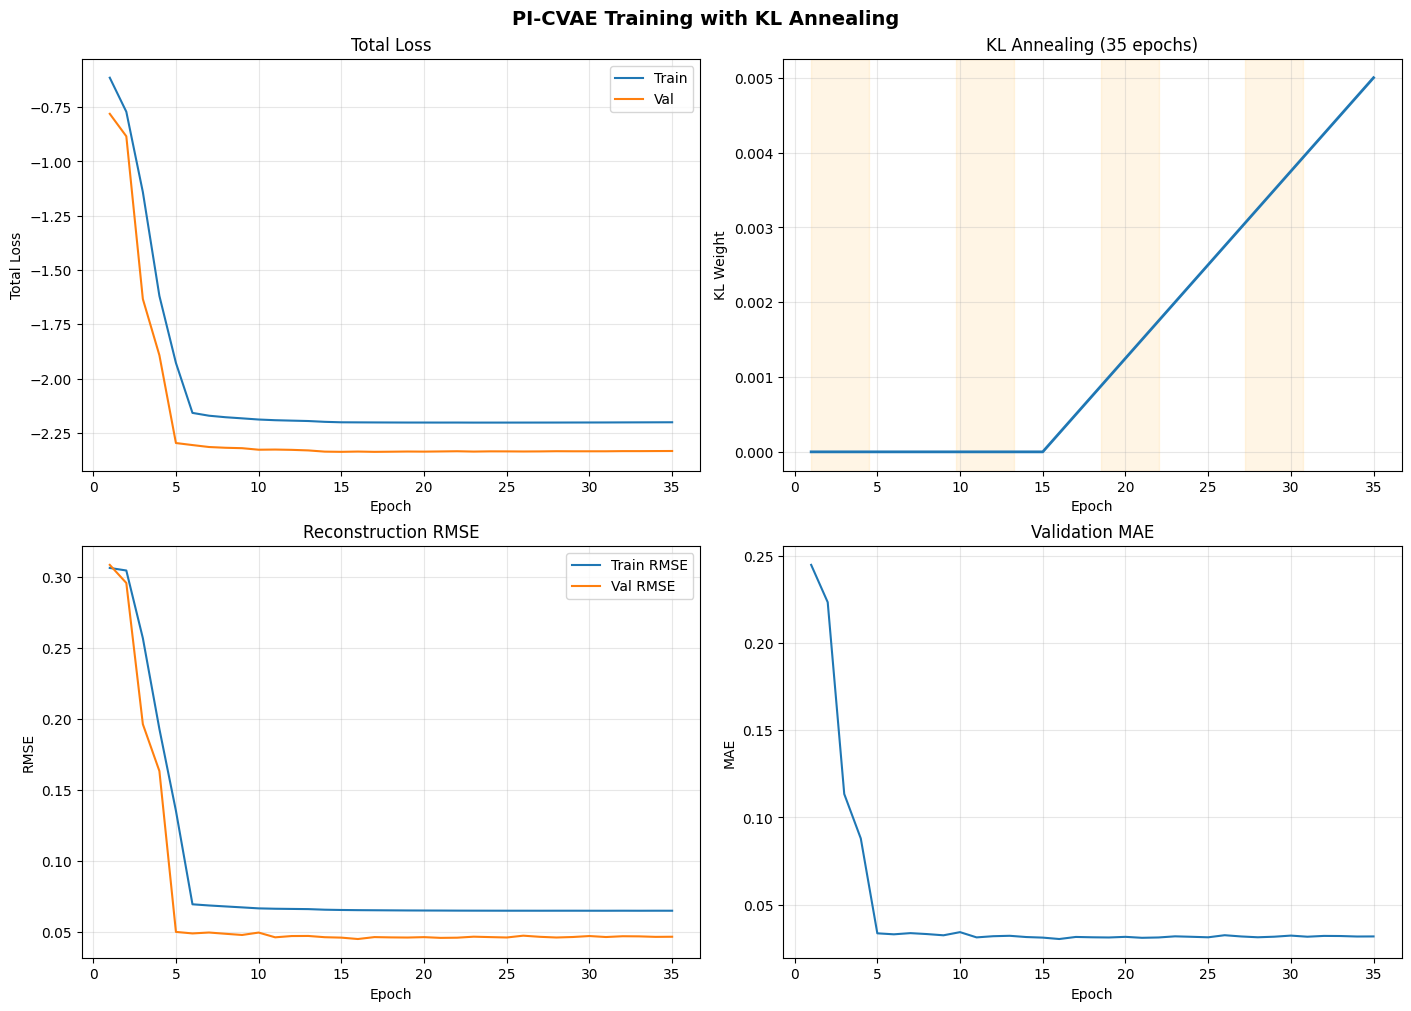

In [43]:
plot_training_history(History, save_path="training_curves.png")

In [44]:
# #Extract IVIM parameters from the trained model
# D, Ds, f = generate_IVIM_params(cvae_model, train_loader, device=device)

# print(f"D shape: {D.shape}, Ds shape: {Ds.shape}, f shape: {f.shape}")
# print(f"D values: {D}, Ds values: {Ds}, f values: {f}")  #Print first 5 values 


## **RECONSTRUCTION OF IMAGE WITH PARAMETERS**

In [45]:
##Visualization of ivim parameters (D,D*,f) estimated by PICVAE
def visualize_ivim_cvae(model, dataloader, brain_msk, b0_image, center_coords=None,
                       device="cuda", slice_idx=27):
    model.eval()
    D_map = np.zeros(brain_msk.shape, dtype=np.float32)
    Ds_map = np.zeros_like(D_map)
    f_map = np.zeros_like(D_map)

    #Physiological ranges
    D_MIN,  D_MAX   = 0.0001, 0.004   #mm²/s
    Ds_MIN, Ds_MAX  = 0.005, 0.020    #mm²/s
    f_MIN,  f_MAX   = 0.000, 0.300    #fraction

    pointer = 0
    with torch.no_grad():
        for x_batch, c_batch in dataloader:
            x_batch = x_batch.to(device)
            #prefer coordinates supplied by the dataloader
            use_batch_coords = True
            if c_batch is None:
                use_batch_coords = False
            else:
                c_batch = c_batch.to(device)

            _, _, _, _, parameters, _, _ = model(x_batch, c_batch if use_batch_coords else torch.zeros((x_batch.size(0), 2), device=device))
            _, D_batch, Ds_batch, f_batch = parameters

            D_batch = D_batch.squeeze(1).cpu().numpy()   #(B,3,3)
            Ds_batch = Ds_batch.squeeze(1).cpu().numpy()
            f_batch = f_batch.squeeze(1).cpu().numpy()

            for i in range(x_batch.size(0)):
                #get coordinate from c_batch if present, else fall back to external center_coords list
                if use_batch_coords:
                    coord = c_batch[i].cpu().numpy().ravel()
                elif center_coords is not None:
                    coord = np.asarray(center_coords[pointer], dtype=np.float32).ravel()
                else:
                    raise ValueError("No coordinates available: pass center coordinates or ensure dataloader yields coords")

                #handle normalized coords in [-1,1]/pixel coords
                if np.all(coord >= -1.0) and np.all(coord <= 1.0):
                    y = int(np.round((coord[0] + 1) * 0.5 * (brain_msk.shape[0] - 1)))
                    x = int(np.round((coord[1] + 1) * 0.5 * (brain_msk.shape[1] - 1)))
                else:
                    #pixel indices(x_row,y_col)
                    y = int(np.round(coord[0]))
                    x = int(np.round(coord[1]))

                y = np.clip(y, 0, brain_msk.shape[0] - 1)
                x = np.clip(x, 0, brain_msk.shape[1] - 1)

                #write center value of predicted 3x3 patch
                D_map[y, x] = D_batch[i, 1, 1]
                Ds_map[y, x] = Ds_batch[i, 1, 1]
                f_map[y, x] = f_batch[i, 1, 1]
                pointer += 1

    #robustly pick b0 slice matching brain_msk
    if b0_image.ndim == 3:
        #try common conventions
        if b0_image.shape == brain_msk.shape:
            raw_structural = b0_image
            raw_structural = raw_structural[:, :, slice_idx]
        elif b0_image.shape[2] == brain_msk.shape[2]:
            raw_structural = b0_image[:, :, slice_idx]
        elif b0_image.shape[0] == brain_msk.shape[2]:
            raw_structural = b0_image[slice_idx, :, :]
        else:
            #try moveaxis fallback
            try:
                b0_try = np.moveaxis(b0_image, 0, -1)
                raw_structural = b0_try[..., slice_idx]
            except Exception:
                raise ValueError("Unable to infer slice axis for b0_image")
    else:
        raw_structural = b0_image

    structural_mask = brain_msk[..., slice_idx] > 0
    structural_underlay = np.where(structural_mask, raw_structural, 0)

    D_masked = np.ma.masked_where(~structural_mask, D_map[:, :, slice_idx])
    Ds_masked = np.ma.masked_where(~structural_mask, Ds_map[:, :, slice_idx])
    f_masked = np.ma.masked_where(~structural_mask, f_map[:, :, slice_idx])

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='black')

    def plot_overlay(ax, structural, parameter, title, cmap, vmin, vmax, label):
        vmax_struct = np.percentile(structural[structural > 0], 98) if np.any(structural > 0) else 1.0
        ax.imshow(structural, cmap='gray', vmax=vmax_struct, origin='lower')
        im = ax.imshow(parameter, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.8, origin='lower')
        ax.set_title(title, color='white', fontsize=14)
        ax.axis('off')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.yaxis.set_tick_params(color='white')
        cbar.set_label(label, color='white')
        plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    plot_overlay(axes[0], structural_underlay, D_masked,
                 f'D Map - Slice {slice_idx}', 'inferno', D_MIN,  D_MAX, 'mm²/s')
    plot_overlay(axes[1], structural_underlay, Ds_masked,
                 f'D* Map - Slice {slice_idx}', 'inferno', Ds_MIN, Ds_MAX, 'mm²/s')
    plot_overlay(axes[2], structural_underlay, f_masked,
                 f'f Map - Slice {slice_idx}', 'inferno', f_MIN,  f_MAX, 'Fraction')
                 

    plt.tight_layout()

    #Save the figure to a memory buffer instead of relying on plt.show()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor='black', dpi=150)
    buf.seek(0)
    
    #Display the image
    display(Image(buf.read()))
    
    #Saving file
    save_filename = f"ivim_maps_slice_{slice_idx}.png"
    fig.savefig(save_filename, dpi=150, bbox_inches='tight', facecolor='black')
    print(f"Plot saved as: {save_filename}")

    plt.close(fig)

    return D_map, Ds_map, f_map

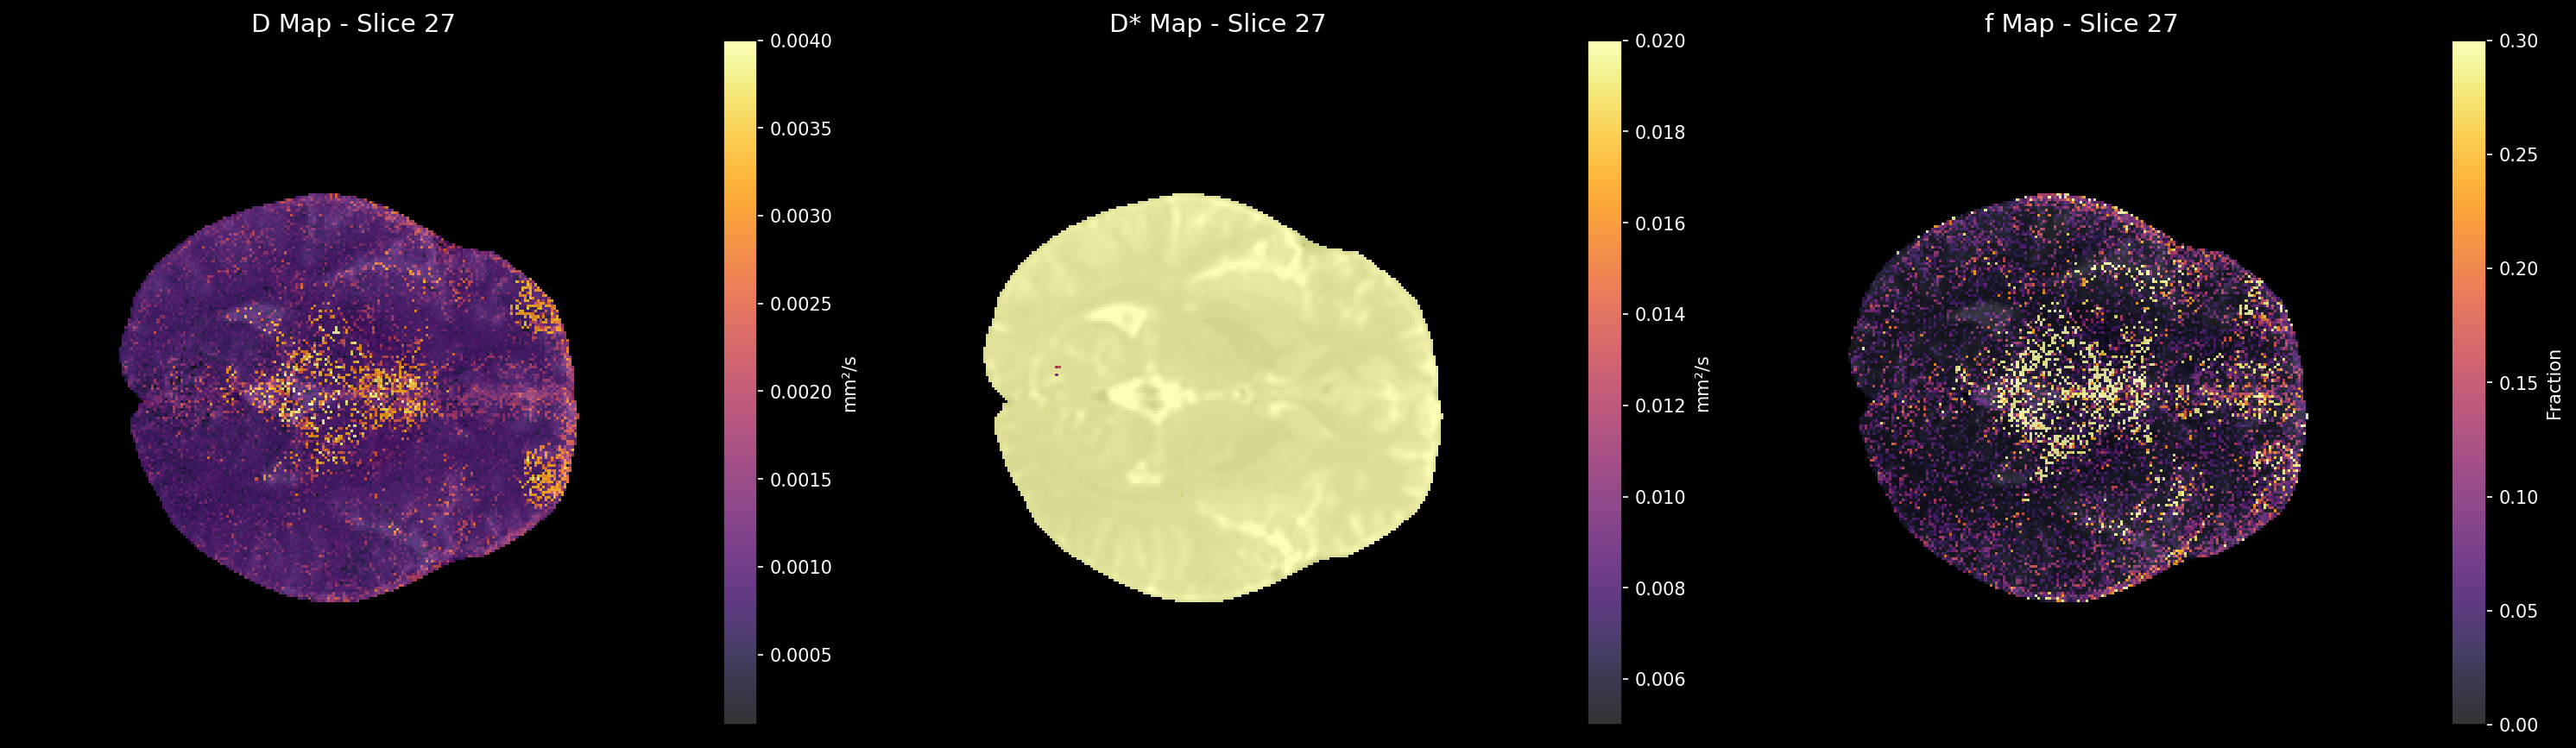

Plot saved as: ivim_maps_slice_27.png


In [46]:
d, ds, f = visualize_ivim_cvae(model=cvae_model, 
                   dataloader=train_loader,
                   brain_msk=brain_msk,
                   b0_image=b0_raw,
                   center_coords=coord_train,
                   device=device.type, 
                   slice_idx=27)

In [ ]:
ds[ds>0]